In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: xlabel='placement_exam_marks', ylabel='Count'>

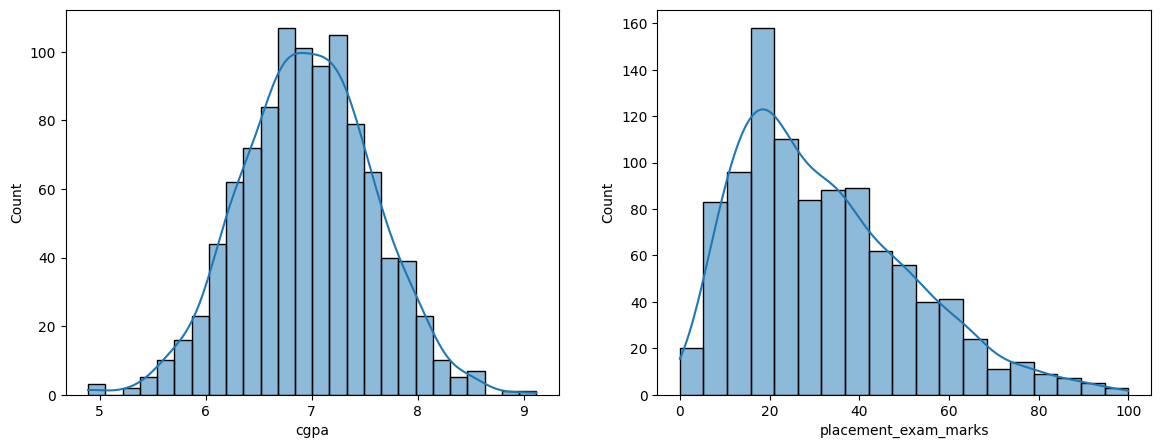

In [12]:
plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde=True)
plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde=True)

Since cgpa has normal distribution so we can use z_score to remove outliers


In [14]:
mean=df['cgpa'].mean()
std=df['cgpa'].std()

In [ ]:
print('Mean value of cgpa',df['cgpa'].mean())
print('S.D value of cgpa',df['cgpa'].std())
print('Min value of cgpa',df['cgpa'].mean())
print('Max value of cgpa',df['cgpa'].mean())

Mean value of cgpa 6.96124


In [15]:
print('Highest allowded value',mean+ 3*std)
print('Lowest allowded value',mean - 3*std)


Highest allowded value 8.808933625397168
Lowest allowded value 5.113546374602832


In [18]:
#Finding the outliers
df[(df['cgpa']>8.80) | (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [ ]:
#removing outliers  using trimming the outliers
df[(df['cgpa']<8.80) | (df['cgpa']>5.11)]

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


# Capping


In [20]:

upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()


In [21]:

df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)
